In [ ]:
# Célula 1: Imports e Configurações Iniciais
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import pandas as pd

# Confirmação visual de que a GPU está ligada
print("GPU ativa:", len(tf.config.list_physical_devices('GPU')) > 0)

GPU ativa: True


In [ ]:
# Célula 2: Download e Preparação do CIFAR-10
(x_train_all, y_train_all), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalização para a escala [0, 1]
x_train_all = x_train_all.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Isolando 10.000 imagens para validação
x_val = x_train_all[-10000:]
y_val = y_train_all[-10000:]
x_train = x_train_all[:-10000]
y_train = y_train_all[:-10000]

print(f"Imagens de Treino: {len(x_train)}")
print(f"Imagens de Validação: {len(x_val)}")

Imagens de Treino: 40000
Imagens de Validação: 10000


In [ ]:
# Célula 3: Função para plotar os gráficos de treinamento
def plot_history(history, model_title):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Treino', color='blue')
    plt.plot(history.history['val_loss'], label='Validação', color='orange')
    plt.title(f'{model_title}: Métrica de Perda (Loss) por Época')
    plt.xlabel('Época')
    plt.ylabel('Valor de Perda')
    plt.legend()
    plt.grid(True)

    # Gráfico de Acurácia
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Treino', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validação', color='orange')
    plt.title(f'{model_title}: Métrica de Acurácia por Época')
    plt.xlabel('Época')
    plt.ylabel('Acurácia (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# Célula 4: Bloco de Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(32, 32, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinando MLP...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3119 - loss: 1.8996 - val_accuracy: 0.3439 - val_loss: 1.7923
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3876 - loss: 1.7019 - val_accuracy: 0.3885 - val_loss: 1.7016
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4217 - loss: 1.6137 - val_accuracy: 0.4195 - val_loss: 1.6375
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4408 - loss: 1.5564 - val_accuracy: 0.4481 - val_loss: 1.5556
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4623 - loss: 1.5008 - val_accuracy: 0.4449 - val_loss: 1.5653
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4766 - loss: 1.4641 - val_accuracy: 0.4554 - val_loss: 1.5277
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4835 - loss: 1.4360 - val_accuracy: 0.4599 - val_loss: 1.5203
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4949 - loss: 1.4066 - val_accuracy: 0.

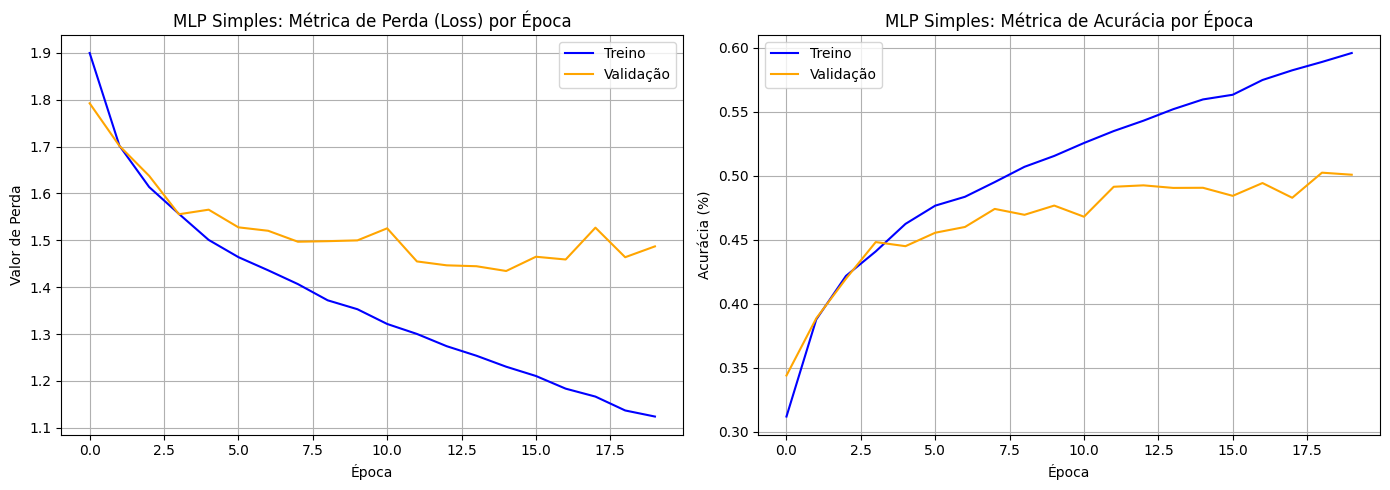

In [ ]:
# Célula 5: Rede Neural Simples (MLP)
model_mlp = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Treinando MLP...")
history_mlp = model_mlp.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

# Chamando a função modular para exibir os resultados
plot_history(history_mlp, "MLP Simples")

Treinando CNN...
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3806 - loss: 1.7013 - val_accuracy: 0.4880 - val_loss: 1.4130
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5002 - loss: 1.3935 - val_accuracy: 0.5208 - val_loss: 1.3642
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5501 - loss: 1.2633 - val_accuracy: 0.6007 - val_loss: 1.1389
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5827 - loss: 1.1789 - val_accuracy: 0.6158 - val_loss: 1.0980
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6056 - loss: 1.1161 - val_accuracy: 0.5959 - val_loss: 1.2111
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6252 - loss: 1.0702 - val_accuracy: 0.6378 - val_loss: 1.0744
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6323 - loss: 1.0409 - val_accuracy: 0.6329 - val_loss: 1.0955
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6467 - loss: 1.0045 

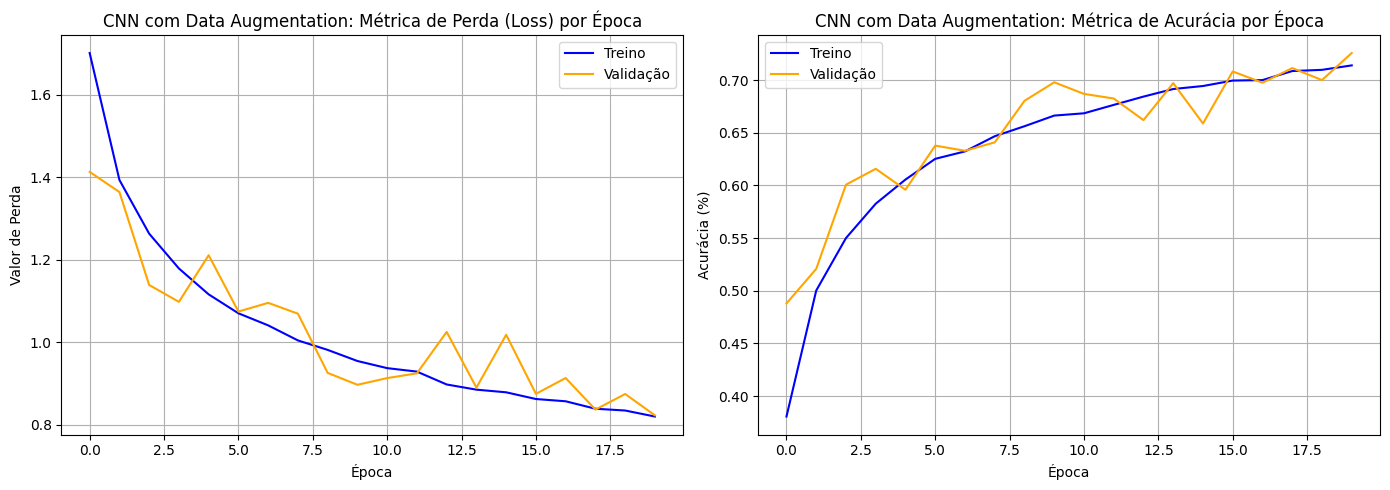

In [ ]:
# Célula 6: Rede Convolucional (CNN) + Data Augmentation
model_cnn = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Treinando CNN...")
history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

# Exibindo os resultados com a função
plot_history(history_cnn, "CNN com Data Augmentation")

In [ ]:
# Célula 7: Otimização de Hiperparâmetros (Grid Search)
hyperparameter_results = []
learning_rates_to_test = [0.001, 0.0001]
dense_units_to_test = [64, 128]
epochs_for_tuning = 10

print("Iniciando a bateria de testes de hiperparâmetros...\n")

for lr in learning_rates_to_test:
    for units in dense_units_to_test:
        print(f"Testando configuração -> Learning Rate: {lr} | Neurônios: {units}")

        model_tune = models.Sequential([
            data_augmentation,
            layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.MaxPooling2D((2, 2)),
            layers.Flatten(),
            layers.Dense(units, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])

        custom_optimizer = optimizers.Adam(learning_rate=lr)
        model_tune.compile(
            optimizer=custom_optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        history_tune = model_tune.fit(
            x_train, y_train,
            epochs=epochs_for_tuning,
            batch_size=64,
            validation_data=(x_val, y_val),
            verbose=0
        )

        hyperparameter_results.append({
            'Learning Rate': lr,
            'Neurônios (Densa)': units,
            'Acurácia de Validação': round(history_tune.history['val_accuracy'][-1], 4),
            'Loss de Validação': round(history_tune.history['val_loss'][-1], 4)
        })

print("\nTestes concluídos!")

tabela_resultados = pd.DataFrame(hyperparameter_results)
tabela_resultados = tabela_resultados.sort_values(by='Acurácia de Validação', ascending=False).reset_index(drop=True)
display(tabela_resultados)

Iniciando a bateria de testes de hiperparâmetros...

Testando configuração -> Learning Rate: 0.001 | Neurônios: 64
Testando configuração -> Learning Rate: 0.001 | Neurônios: 128
Testando configuração -> Learning Rate: 0.0001 | Neurônios: 64
Testando configuração -> Learning Rate: 0.0001 | Neurônios: 128

Testes concluídos!


,Learning Rate,Neurônios (Densa),Acurácia de Validação,Loss de Validação
0,0.0010,128,0.7024,0.8624
1,0.0010,64,0.6720,0.9412
2,0.0001,64,0.5264,1.3677
3,0.0001,128,0.5238,1.3503


Treinando o modelo definitivo (LR=0.001, Neurônios=128)...
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4002 - loss: 1.6463 - val_accuracy: 0.5003 - val_loss: 1.4298
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5173 - loss: 1.3393 - val_accuracy: 0.5852 - val_loss: 1.1860
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5694 - loss: 1.2109 - val_accuracy: 0.6123 - val_loss: 1.1121
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5965 - loss: 1.1340 - val_accuracy: 0.6533 - val_loss: 0.9875
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6215 - loss: 1.0745 - val_accuracy: 0.6666 - val_loss: 0.9788
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6357 - loss: 1.0281 - val_accuracy: 0.6618 - val_loss: 0.9950
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6521 - loss: 0.9861 - val_accuracy: 0.6707 - val_loss: 0.9953
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9

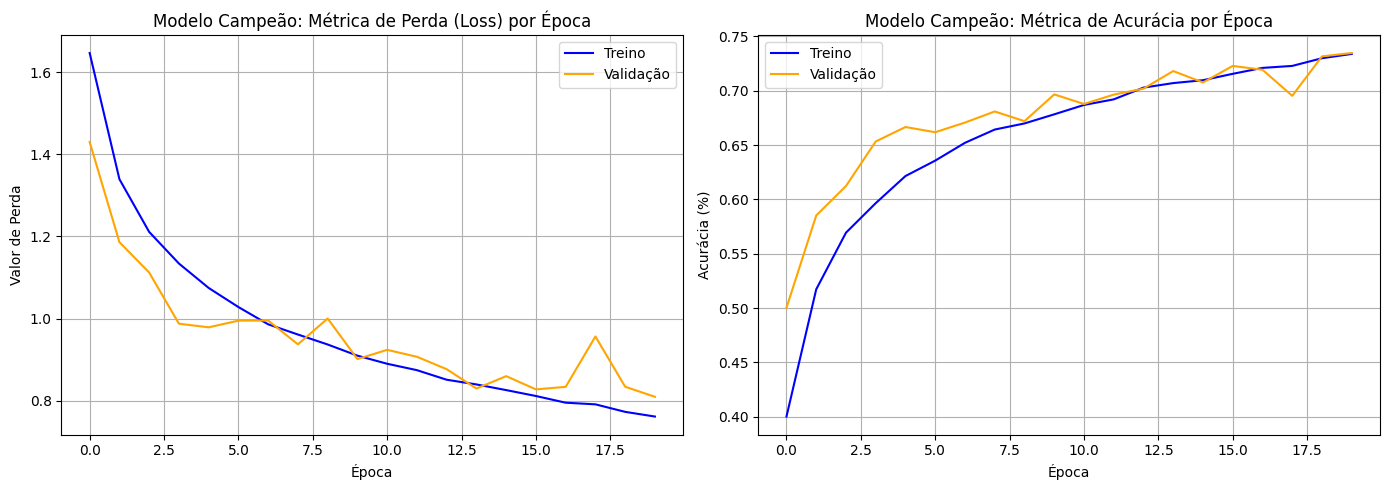


--- AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7192 - loss: 0.8143

Acurácia Final no Teste: 71.92%
Loss Final no Teste: 0.8143


In [ ]:
# Célula 8: Avaliação Final com Dados de Teste
print("Treinando o modelo definitivo (LR=0.001, Neurônios=128)...")

best_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

best_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

best_history = best_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

plot_history(best_history, "Modelo Campeão")

print("\n--- AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---")
test_loss, test_acc = best_model.evaluate(x_test, y_test)

print(f"\nAcurácia Final no Teste: {test_acc*100:.2f}%")
print(f"Loss Final no Teste: {test_loss:.4f}")